In [10]:
import json
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from train_tune_sklearn import engineer_features_dayahead, prepare_Xy
from tools import DataProcessor


DATA_FOLDER  = "./data"
MODEL_DIR    = Path("./models/nodrop")
MODEL_TYPE   = "lightgbm"          # random_forest | lightgbm | xgboost
EVAL_POINT   = 5471                 
SITE_FILTER  = None                # None = tous les sites, ou ex. "Belwind Phase 1"


In [11]:
# ------------------------------------------------------------
# 1. Reconstruction du jeu d'évaluation (même pipeline qu'à l'entraînement)
# ------------------------------------------------------------
processor = DataProcessor(DATA_FOLDER)
df = processor.prepocess_data()
df = engineer_features_dayahead(df)
df.drop(columns=[c for c in ["production", "installed_capacity"] if c in df.columns], inplace=True)
df = df.sort_values("delivery_time").reset_index(drop=True)

df_eval = df.iloc[-EVAL_POINT:].copy()

if SITE_FILTER:
    if SITE_FILTER not in df_eval["site_name"].unique():
        raise Exception("Unknown site, please enter a valid name")
    df_eval = df_eval[df_eval["site_name"] == SITE_FILTER]

X_eval, y_true = prepare_Xy(df_eval)



In [12]:
# ------------------------------------------------------------
# 2. Chargement du modèle et prédiction
# ------------------------------------------------------------
model      = joblib.load(MODEL_DIR / f"{MODEL_TYPE}_model.joblib")
metrics    = json.loads((MODEL_DIR / f"{MODEL_TYPE}_metrics.json").read_text())
y_pred     = model.predict(X_eval)
y_pred     = np.clip(y_pred, 0, 1)   # production normalisée ∈ [0, 1]

timestamps = df_eval["delivery_time"].values
sites      = df_eval["site_name"].values if "site_name" in df_eval.columns else np.array(["global"] * len(df_eval))

# Métriques hold-out
mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2   = r2_score(y_true, y_pred)
bias = float(np.mean(y_pred - y_true))

print(f"{'MAE':<8} {mae:.4f}")
print(f"{'RMSE':<8} {rmse:.4f}")
print(f"{'R²':<8} {r2:.4f}")
print(f"{'Biais':<8} {bias:+.4f}  ({'surestimation' if bias > 0 else 'sous-estimation'})")

MAE      0.1000
RMSE     0.1369
R²       0.8234
Biais    -0.0247  (sous-estimation)


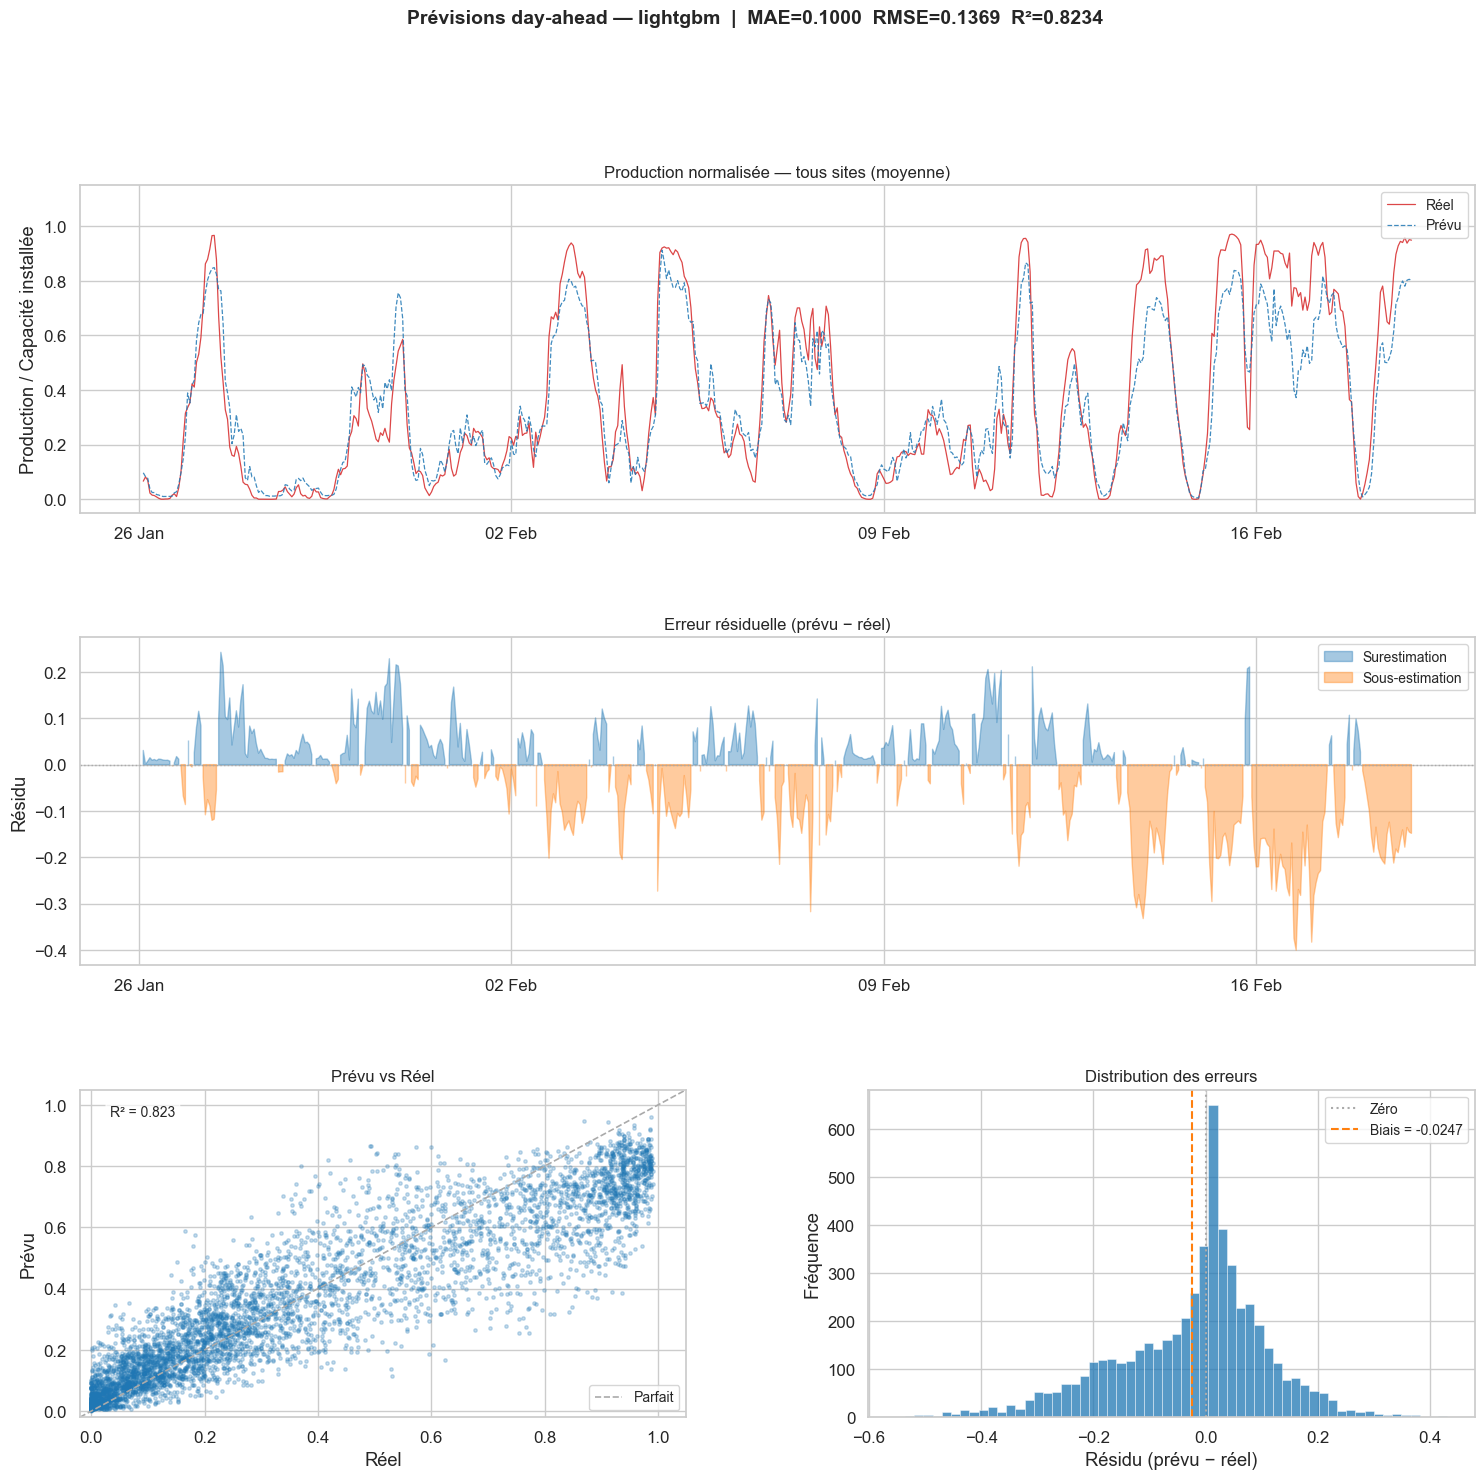

Figure sauvegardée → models\nodrop\lightgbm_eval.png


In [13]:
# ------------------------------------------------------------
# 3. Figures
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {"pred": "#1f77b4", "true": "#d62728", "error": "#ff7f0e", "zero": "#aaaaaa"}

fig = plt.figure(figsize=(18, 16))
fig.suptitle(
    f"Prévisions day-ahead — {MODEL_TYPE}  |  "
    f"MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}",
    fontsize=14, fontweight="bold", y=0.99,
)
gs = fig.add_gridspec(3, 2, hspace=0.38, wspace=0.3)

# ── 3a. Série temporelle : prévu vs réel (premier site ou agrégat) ──────────
ax1 = fig.add_subplot(gs[0, :])

if SITE_FILTER or len(np.unique(sites)) == 1:
    mask = np.ones(len(df_eval), dtype=bool)
    site_label = sites[0]
else:
    # Moyenne horaire sur tous les sites pour lisibilité
    tmp = pd.DataFrame({"ts": timestamps, "true": y_true.values, "pred": y_pred})
    tmp = tmp.groupby("ts").mean().reset_index()
    timestamps_plot = pd.to_datetime(tmp["ts"])
    ax1.plot(timestamps_plot, tmp["true"], color=COLORS["true"],  lw=0.9, label="Réel",   alpha=0.85)
    ax1.plot(timestamps_plot, tmp["pred"], color=COLORS["pred"],  lw=0.9, label="Prévu",  alpha=0.85, linestyle="--")
    site_label = "tous sites (moyenne)"
    mask = None

if mask is not None:
    ts_plot = pd.to_datetime(timestamps[mask])
    ax1.plot(ts_plot, y_true.values[mask],  color=COLORS["true"], lw=0.9, label="Réel",  alpha=0.85)
    ax1.plot(ts_plot, y_pred[mask],          color=COLORS["pred"], lw=0.9, label="Prévu", alpha=0.85, linestyle="--")

ax1.set_title(f"Production normalisée — {site_label}", fontsize=12)
ax1.set_ylabel("Production / Capacité installée")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax1.legend(loc="upper right", fontsize=10)
ax1.set_ylim(-0.05, 1.15)

# ── 3b. Erreur résiduelle dans le temps ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
residuals = y_pred - y_true.values

if mask is None:
    tmp_r = pd.DataFrame({"ts": timestamps, "res": residuals})
    tmp_r = tmp_r.groupby("ts").mean().reset_index()
    ts_r  = pd.to_datetime(tmp_r["ts"])
    res_r = tmp_r["res"].values
else:
    ts_r  = pd.to_datetime(timestamps[mask])
    res_r = residuals[mask]

ax2.axhline(0, color=COLORS["zero"], lw=1, linestyle=":")
ax2.fill_between(ts_r, res_r, 0,
                 where=(res_r > 0), color=COLORS["pred"],  alpha=0.4, label="Surestimation")
ax2.fill_between(ts_r, res_r, 0,
                 where=(res_r < 0), color=COLORS["error"], alpha=0.4, label="Sous-estimation")
ax2.set_title("Erreur résiduelle (prévu − réel)", fontsize=12)
ax2.set_ylabel("Résidu")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax2.legend(loc="upper right", fontsize=10)

# ── 3c. Scatter prévu vs réel ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.scatter(y_true, y_pred, alpha=0.25, s=6, color=COLORS["pred"], rasterized=True)
lims = [-0.02, 1.05]
ax3.plot(lims, lims, color=COLORS["zero"], lw=1.2, linestyle="--", label="Parfait")
ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_xlabel("Réel"); ax3.set_ylabel("Prévu")
ax3.set_title("Prévu vs Réel", fontsize=12)
ax3.legend(fontsize=10)
ax3.text(0.05, 0.92, f"R² = {r2:.3f}", transform=ax3.transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# ── 3d. Distribution des erreurs ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(residuals, bins=60, color=COLORS["pred"], alpha=0.75, edgecolor="white", linewidth=0.4)
ax4.axvline(0,    color=COLORS["zero"],  lw=1.5, linestyle=":", label="Zéro")
ax4.axvline(bias, color=COLORS["error"], lw=1.5, linestyle="--",
            label=f"Biais = {bias:+.4f}")
ax4.set_xlabel("Résidu (prévu − réel)"); ax4.set_ylabel("Fréquence")
ax4.set_title("Distribution des erreurs", fontsize=12)
ax4.legend(fontsize=10)

# plt.savefig(MODEL_DIR / f"{MODEL_TYPE}_eval.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée → {MODEL_DIR / f'{MODEL_TYPE}_eval.png'}")


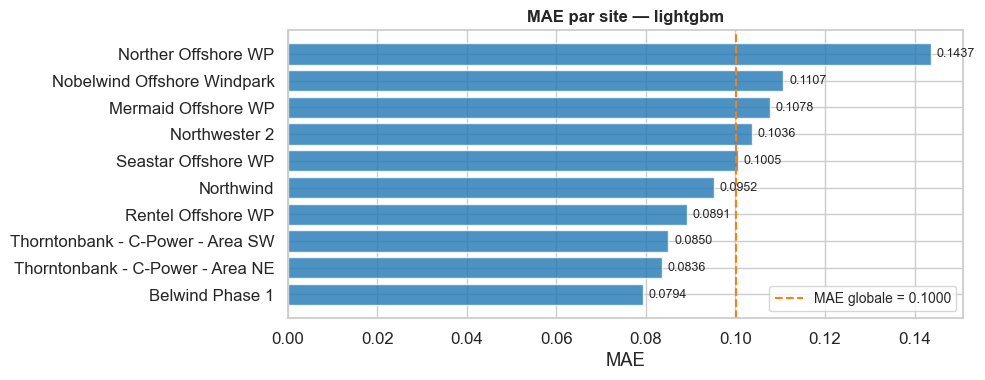

In [14]:
# ------------------------------------------------------------
# 4. MAE par site (si plusieurs sites)
# ------------------------------------------------------------
unique_sites = np.unique(sites)
if len(unique_sites) > 1:
    site_maes = {}
    for s in unique_sites:
        m = sites == s
        site_maes[s] = mean_absolute_error(y_true.values[m], y_pred[m])

    fig2, ax = plt.subplots(figsize=(10, 4))
    sorted_sites = sorted(site_maes, key=site_maes.get)
    bars = ax.barh(sorted_sites, [site_maes[s] for s in sorted_sites],
                   color=COLORS["pred"], alpha=0.8, edgecolor="white")
    ax.axvline(mae, color=COLORS["error"], lw=1.5, linestyle="--", label=f"MAE globale = {mae:.4f}")
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_xlabel("MAE")
    ax.set_title(f"MAE par site — {MODEL_TYPE}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    # plt.savefig(MODEL_DIR / f"{MODEL_TYPE}_mae_par_site.png", dpi=150, bbox_inches="tight")
    plt.show()

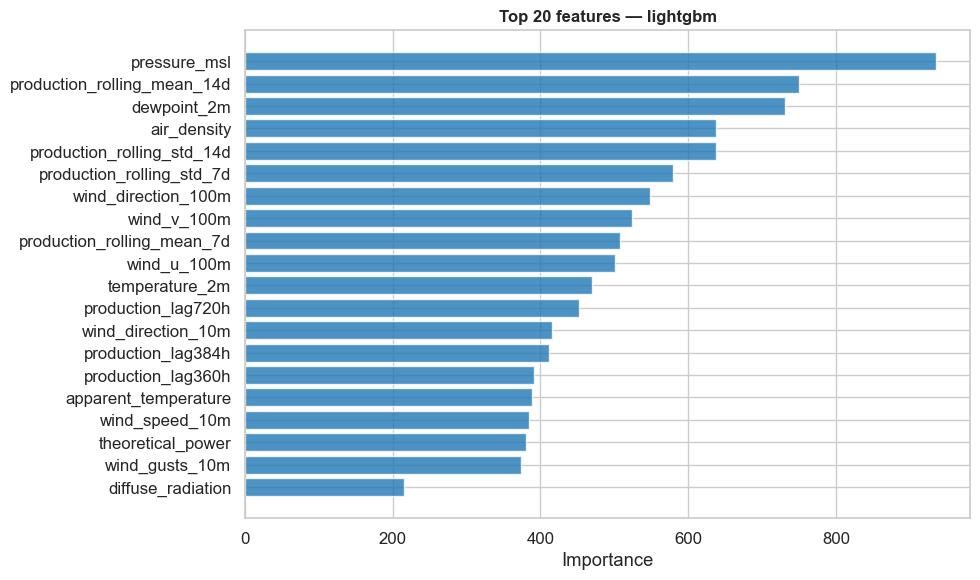

In [15]:
# ------------------------------------------------------------
# 5. Importance des features (si disponible)
# ------------------------------------------------------------
feature_names = json.loads((MODEL_DIR / f"{MODEL_TYPE}_features.json").read_text())

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    top_n = 20
    idx = np.argsort(importances)[-top_n:]

    fig3, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        [feature_names[i] for i in idx],
        importances[idx],
        color=COLORS["pred"], alpha=0.8, edgecolor="white",
    )
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_n} features — {MODEL_TYPE}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    # plt.savefig(MODEL_DIR / f"{MODEL_TYPE}_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

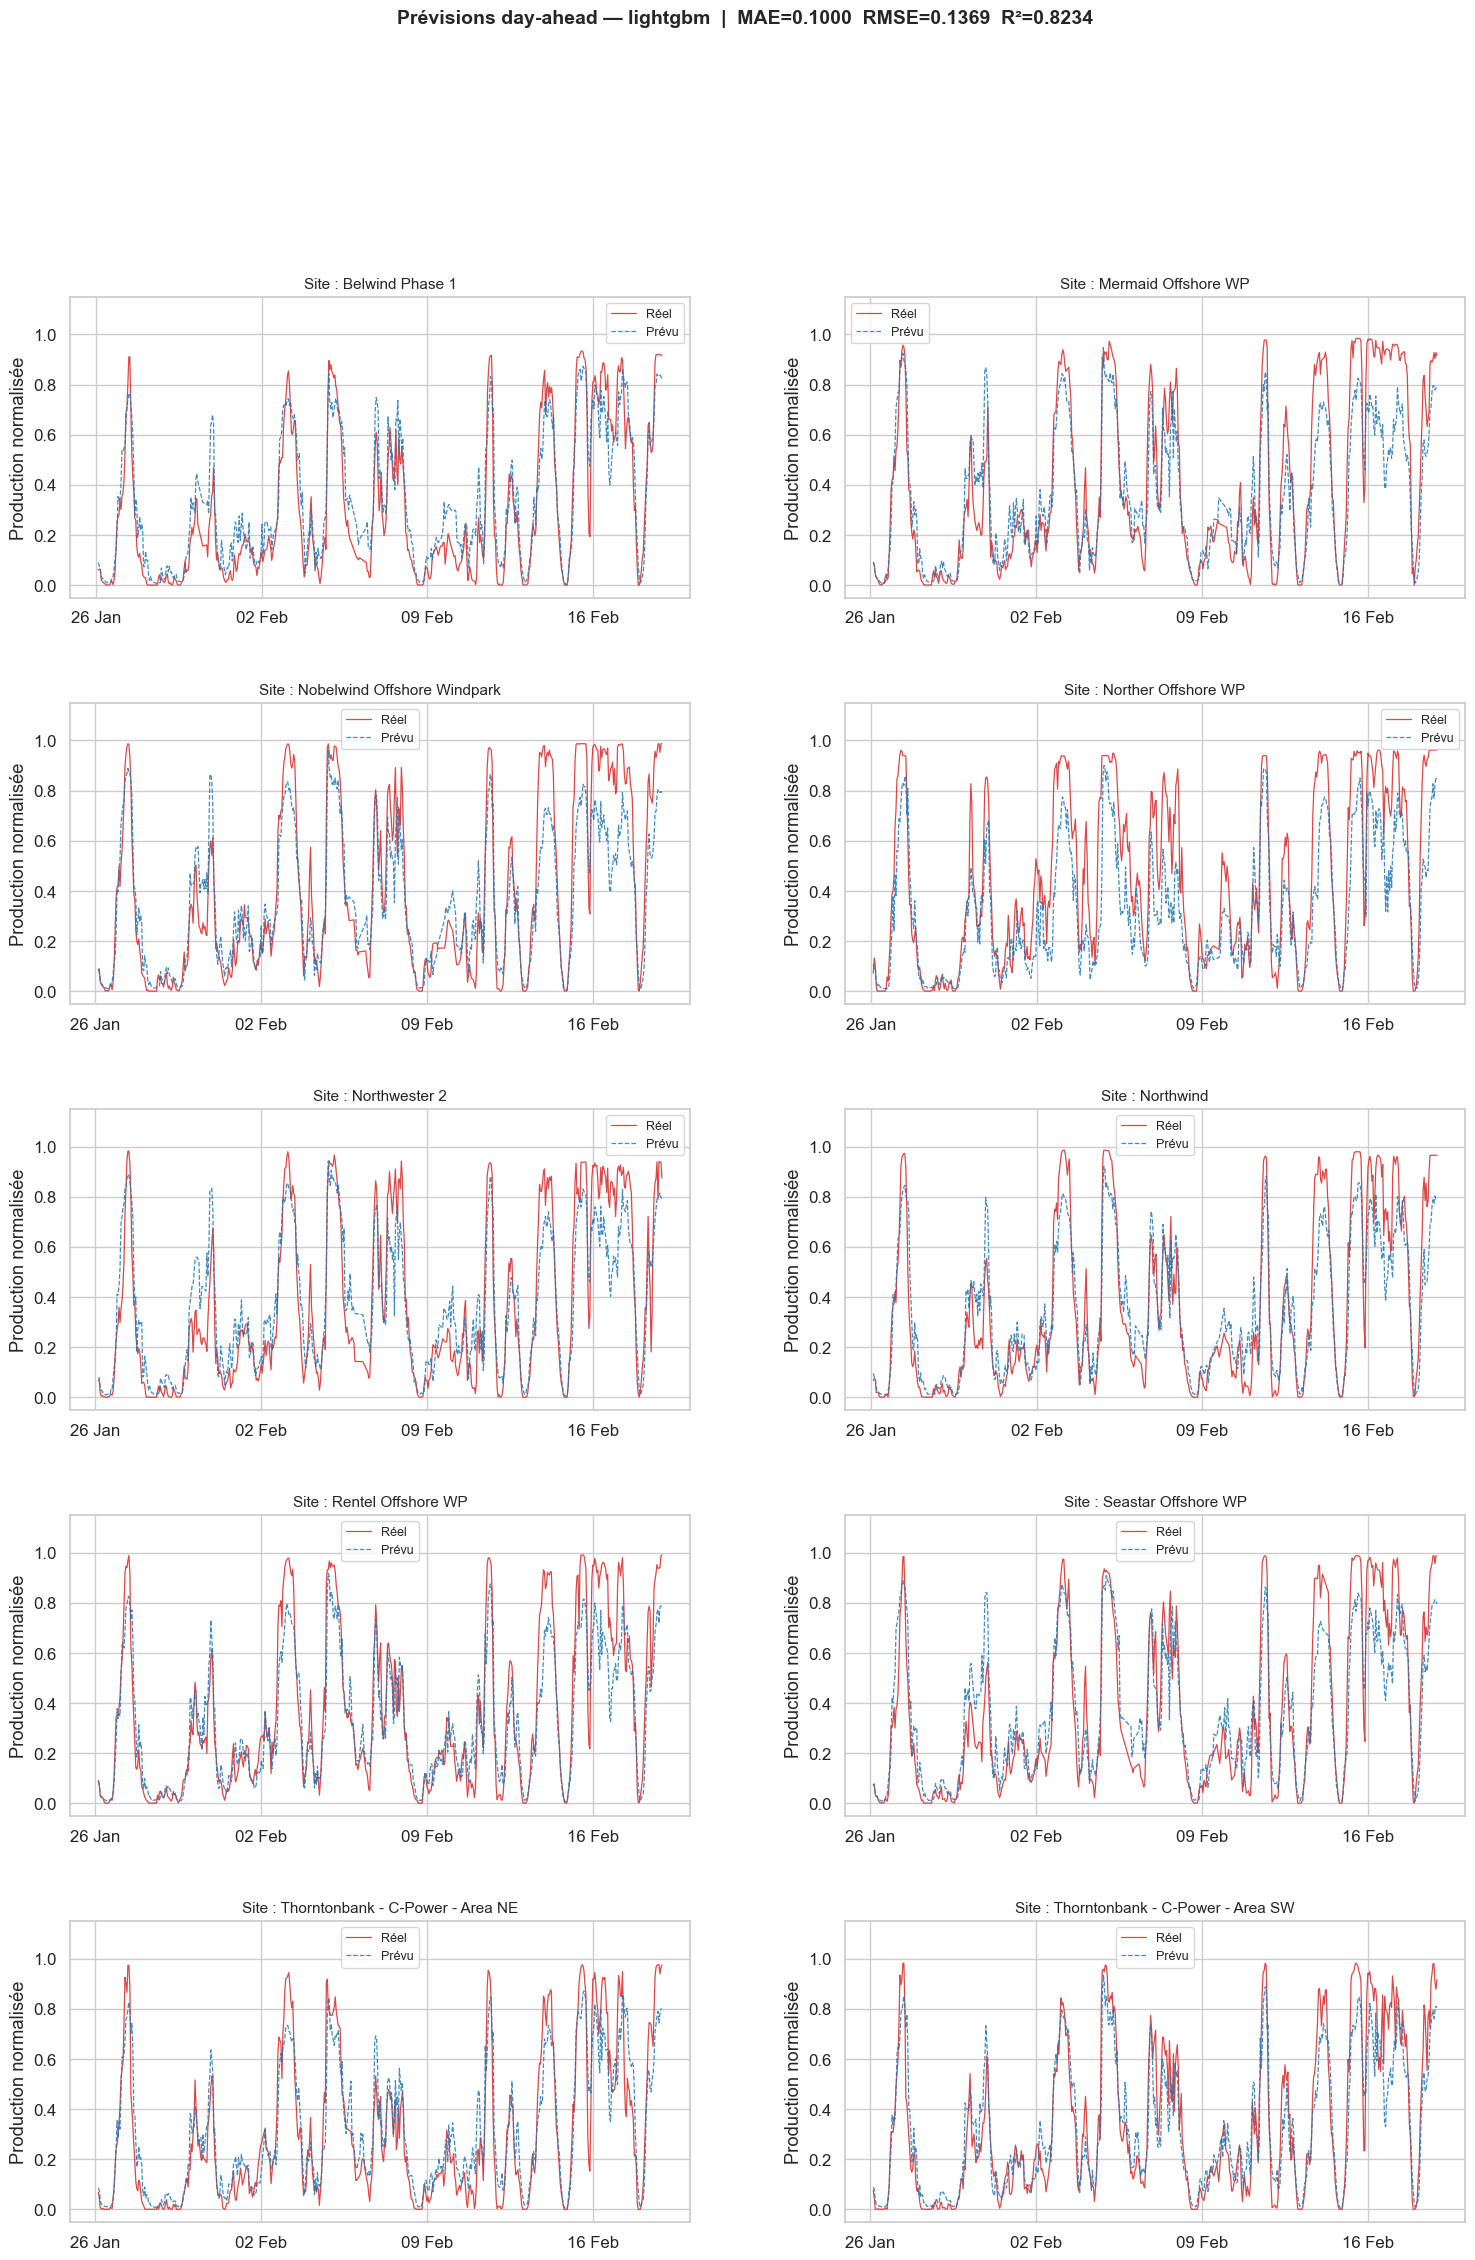

In [18]:
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {"pred": "#1f77b4", "true": "#d62728"}

# Liste des sites uniques
unique_sites = np.unique(sites)
n_sites = len(unique_sites)

# Organisation des subplots (2 colonnes par ex.)
n_cols = 2
n_rows = int(np.ceil(n_sites / n_cols))

fig = plt.figure(figsize=(18, 5 * n_rows))
fig.suptitle(
    f"Prévisions day-ahead — {MODEL_TYPE}  |  "
    f"MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}",
    fontsize=14, fontweight="bold", y=0.995,
)

gs = fig.add_gridspec(n_rows, n_cols, hspace=0.35, wspace=0.25)

# ── Boucle sur les sites ───────────────────────────────────────────────
for i, site in enumerate(unique_sites):
    ax = fig.add_subplot(gs[i // n_cols, i % n_cols])

    # Masque du site
    mask = (sites == site)

    ts_plot = pd.to_datetime(timestamps[mask])

    ax.plot(ts_plot, y_true.values[mask],
            color=COLORS["true"], lw=0.9, label="Réel", alpha=0.85)

    ax.plot(ts_plot, y_pred[mask],
            color=COLORS["pred"], lw=0.9, linestyle="--", label="Prévu", alpha=0.85)

    ax.set_title(f"Site : {site}", fontsize=11)
    ax.set_ylabel("Production normalisée")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)

# Supprime les axes vides si nb impair
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(fig.add_subplot(gs[j // n_cols, j % n_cols]))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()